---
title: Site location problems where certain sites must be included 
image: image.png
execute: 
  enabled: true
---

Sometimes, we may have a series of sites that need to be included in any given solution. For example, you might have 3 existing sites and be looking to add one additional one while not closing any of the others. 

Lokigi allows you to do this by specifying the sites that must be included when you add your sites to the SiteProblem object. 

First, lets do our imports and set up a standard lokigi problem without any sites that must be included. 

In [12]:
from lokigi.site import SiteProblem

In [13]:
problem = SiteProblem()
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson", candidate_id_col="site")
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )
problem.add_region_geometry_layer("https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson", common_col="LSOA11NM")

We can solve this problem for 4 sites of 6 possible candidate locations, minimizing the weighted travel time in this case (a p-median problem). 

In [14]:
solutions = problem.solve(p=4, objectives="p_median")
solutions.show_solutions()

  0%|          | 0/15 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Site 1, Site 3, Site 4, Site 5]","[0, 2, 3, 4]",None,5.08,5.12,7.82,16.69,0.0,LSOA L...
1,2,"[Site 3, Site 4, Site 5, Site 6]","[2, 3, 4, 5]",None,5.11,5.05,7.42,16.69,0.0,LSOA L...
2,3,"[Site 2, Site 3, Site 4, Site 6]","[1, 2, 3, 5]",None,5.20,5.07,7.75,16.69,0.0,LSOA L...
3,4,"[Site 1, Site 2, Site 3, Site 4]","[0, 1, 2, 3]",None,5.22,5.21,8.34,16.69,0.0,LSOA L...
4,5,"[Site 1, Site 3, Site 4, Site 6]","[0, 2, 3, 5]",None,5.23,5.19,8.06,16.69,0.0,LSOA L...
5,6,"[Site 2, Site 3, Site 4, Site 5]","[1, 2, 3, 4]",None,5.28,5.33,8.32,16.69,0.0,LSOA L...
6,7,"[Site 1, Site 3, Site 5, Site 6]","[0, 2, 4, 5]",None,6.05,5.90,9.07,16.69,0.0,LSOA L...
7,8,"[Site 1, Site 2, Site 3, Site 6]","[0, 1, 2, 5]",None,6.14,5.92,9.33,16.69,0.0,LSOA L...
8,9,"[Site 1, Site 2, Site 3, Site 5]","[0, 1, 2, 4]",None,6.24,6.17,9.69,16.69,0.0,LSOA L...
9,10,"[Site 2, Site 3, Site 5, Site 6]","[1, 2, 4, 5]",None,6.33,6.17,9.26,16.69,0.0,LSOA L...


Let's plot some of the best solutions. 

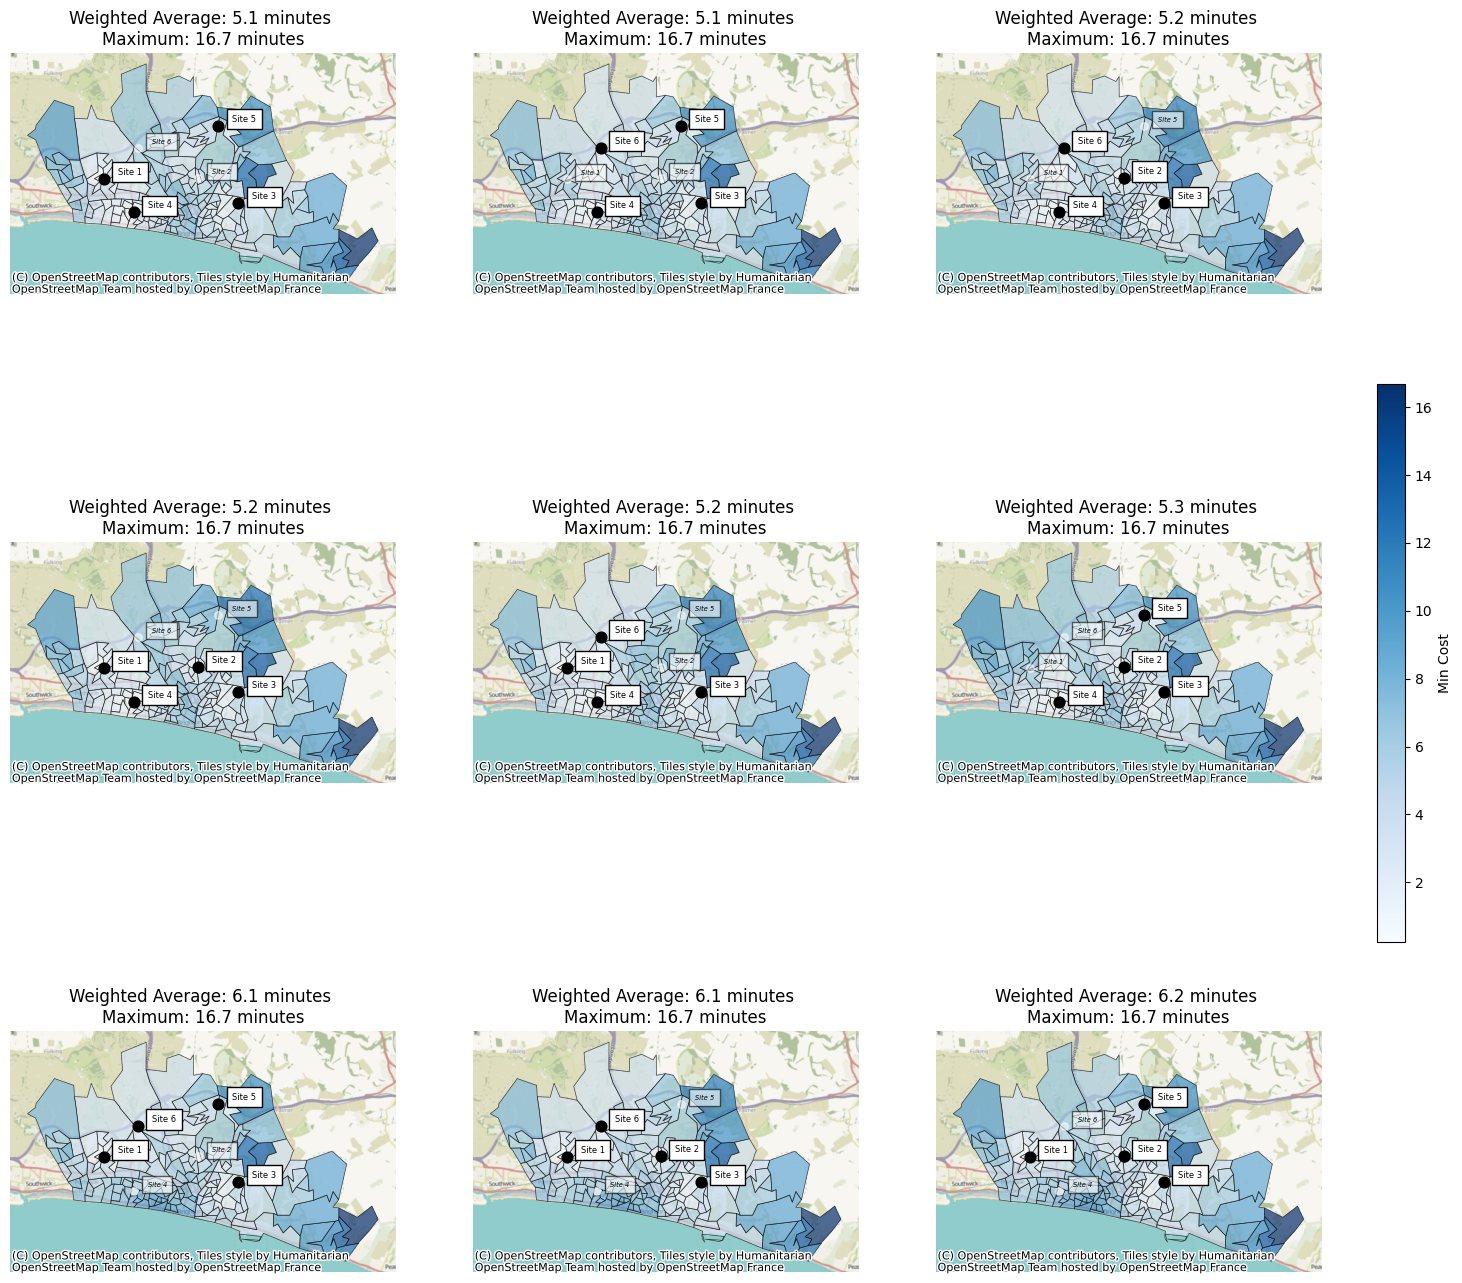

In [15]:
solutions.plot_n_best_combinations(n_best=9, n_cols=3, show_all_locations=True, label_all_locations=True);

However, looking at our sites, we can see there's another column this time that specifies whether the site must be included, and the version of our code above hasn't taken that into account. 

In [16]:
problem.show_sites()

,canonical_site_index,site,existing,geometry
0,0,Site 1,Y,POINT (527142.275 106616.053)
1,1,Site 2,Y,POINT (531493.995 106639.488)
2,2,Site 3,N,POINT (533356.778 105476.782)
3,3,Site 4,N,POINT (528513.424 105052.43)
4,4,Site 5,N,POINT (532421.163 109069.196)
5,5,Site 6,N,POINT (528716.452 108042.794)


So a lot of the solutions provided wouldn't be valid. 

Let's reimport this sites data, but this time passing in a new parameter that lokigi supports - the `required_sites_col` parameter. 

This will then look for common options in that column that could indicate that a site must be included in the final solution: 
`"Yes"`, `"yes"`, `"Y"`, `"y"`, `True`, `true`, or `1.`

In [ ]:
problem_site_constraint = problem.copy()

problem_site_constraint.add_sites("../../../sample_data/brighton_sites_existing.geojson",
                  candidate_id_col="site",
                  required_sites_col="existing" # <1>
                  )


1. This is where we have indicated the new parameter.

Now we will solve again. 

:::{.callout-tip}
Note that we don't need to specify anything different in our call to `.solve()` - it will automatically look for the required_sites_col if we've passed that in when setting up the problem. 
:::

:::{.callout-warning}
Required sites are currently only supported when using the brute force algorithm (which is the default algorithm). Support for use with greedy and GRASP is coming soon! 
:::

In [18]:
solutions_existing_site_constraint = problem_site_constraint.solve(p=4, objectives="p_median")
len(solutions_existing_site_constraint.show_solutions())

  0%|          | 0/6 [00:00<?, ?it/s]

6

In [19]:
solutions_existing_site_constraint.show_solutions()

,solution_rank,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,1,"[Site 1, Site 2, Site 3, Site 4]","[0, 1, 2, 3]",None,5.22,5.21,8.34,16.69,0.0,LSOA L...
1,2,"[Site 1, Site 2, Site 3, Site 6]","[0, 1, 2, 5]",None,6.14,5.92,9.33,16.69,0.0,LSOA L...
2,3,"[Site 1, Site 2, Site 3, Site 5]","[0, 1, 2, 4]",None,6.24,6.17,9.69,16.69,0.0,LSOA L...
3,4,"[Site 1, Site 2, Site 4, Site 5]","[0, 1, 3, 4]",None,6.63,6.43,11.32,21.71,0.0,LSOA L...
4,5,"[Site 1, Site 2, Site 4, Site 6]","[0, 1, 3, 5]",None,6.83,6.48,11.58,22.86,0.0,LSOA L...
5,6,"[Site 1, Site 2, Site 5, Site 6]","[0, 1, 4, 5]",None,7.67,7.27,11.67,21.71,0.0,LSOA L...


We can see that this time far fewer possible solutions have been passed back - only those that meet the criteria of having the specified sites included. 

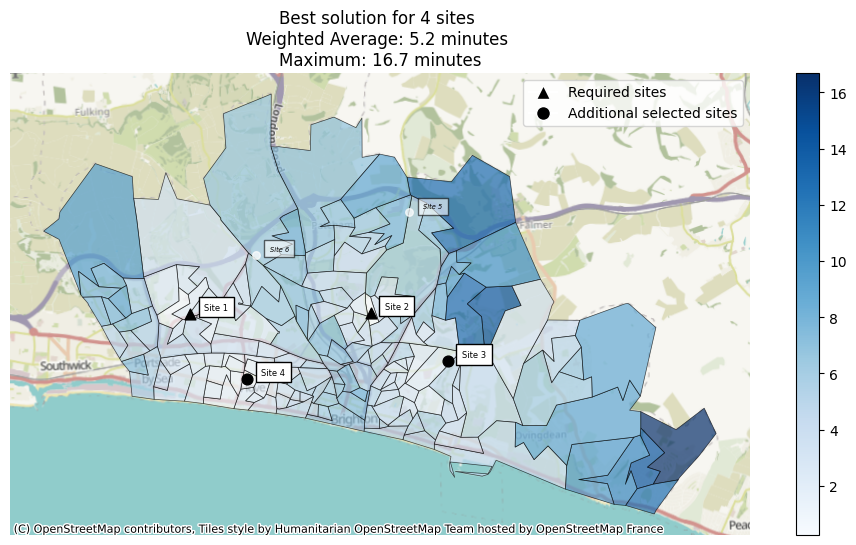

In [20]:
solutions_existing_site_constraint.plot_best_combination(show_all_locations=True, label_all_locations=True);

C:\lokigi\lokigi\mixins\site_solution_plots.py:1095: UserWarning: n_best parameter higher than number of available solutions. Returning 6 solutions.
  warn(


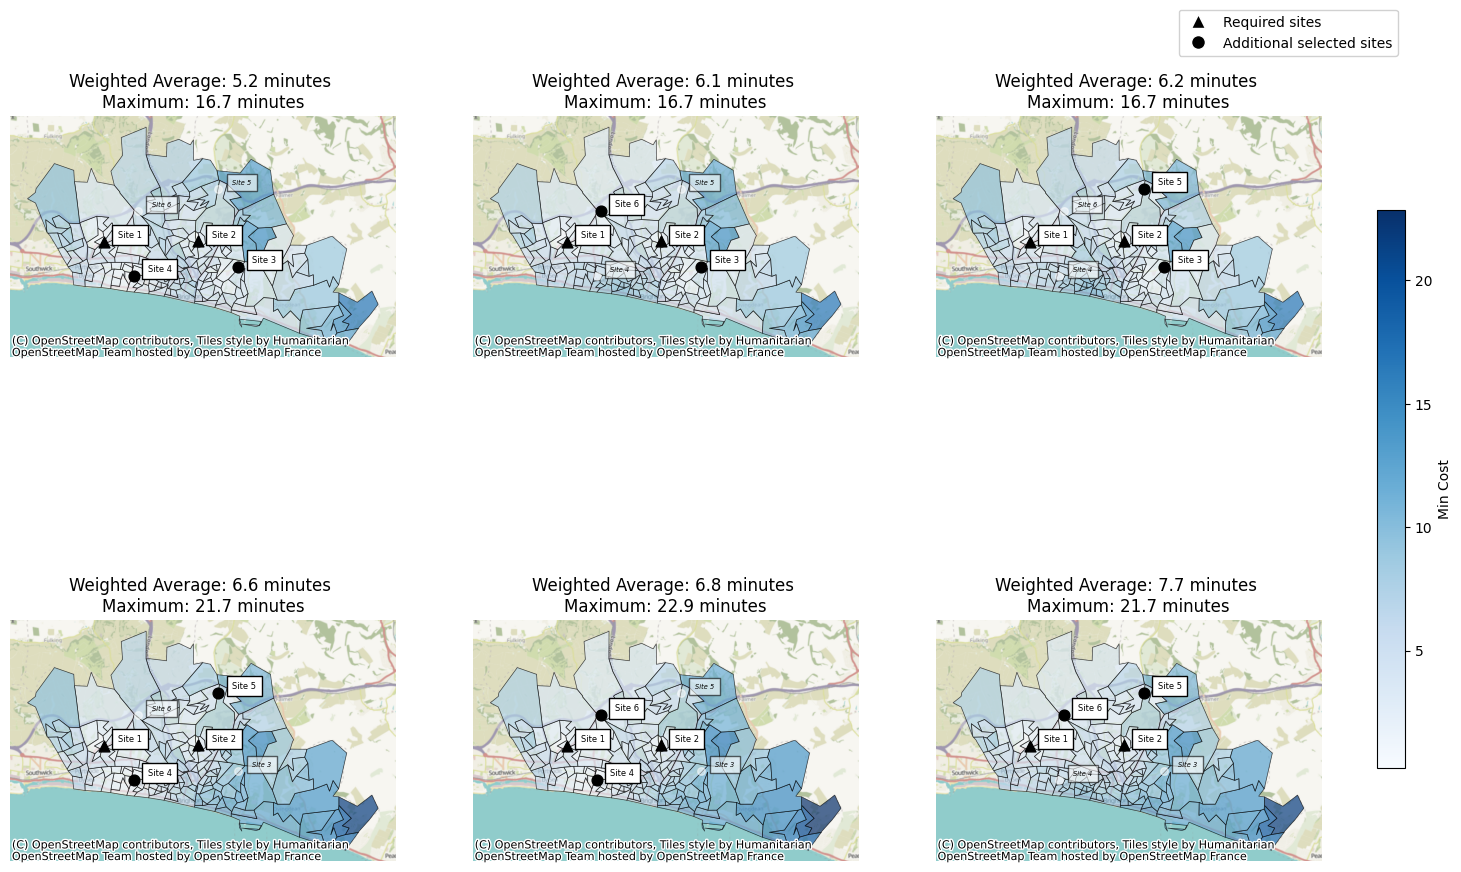

In [21]:
solutions_existing_site_constraint.plot_n_best_combinations(n_cols=3, show_all_locations=True, label_all_locations=True);

Because of the constraints provied, the best solution here (weighted average travel time of 5.2 minutes for sites 1, 2, 3 and 4) is very slightly worse than the unconstrained best solution (weighted average travel time of 5.1 minutes for sites 1, 3, 4 and 5). 

In addition, we can see that the three worst solutions, which don't include site 3, have a worse travel time for the LSOA in the bottom right hand corner, which is contributing to a significantly worse maximum travel time for those solutions. 

### Bonus: Plotting a comparison

For full details, head to the [comparing solutions](../comparing_solutions/index.ipynb) section.

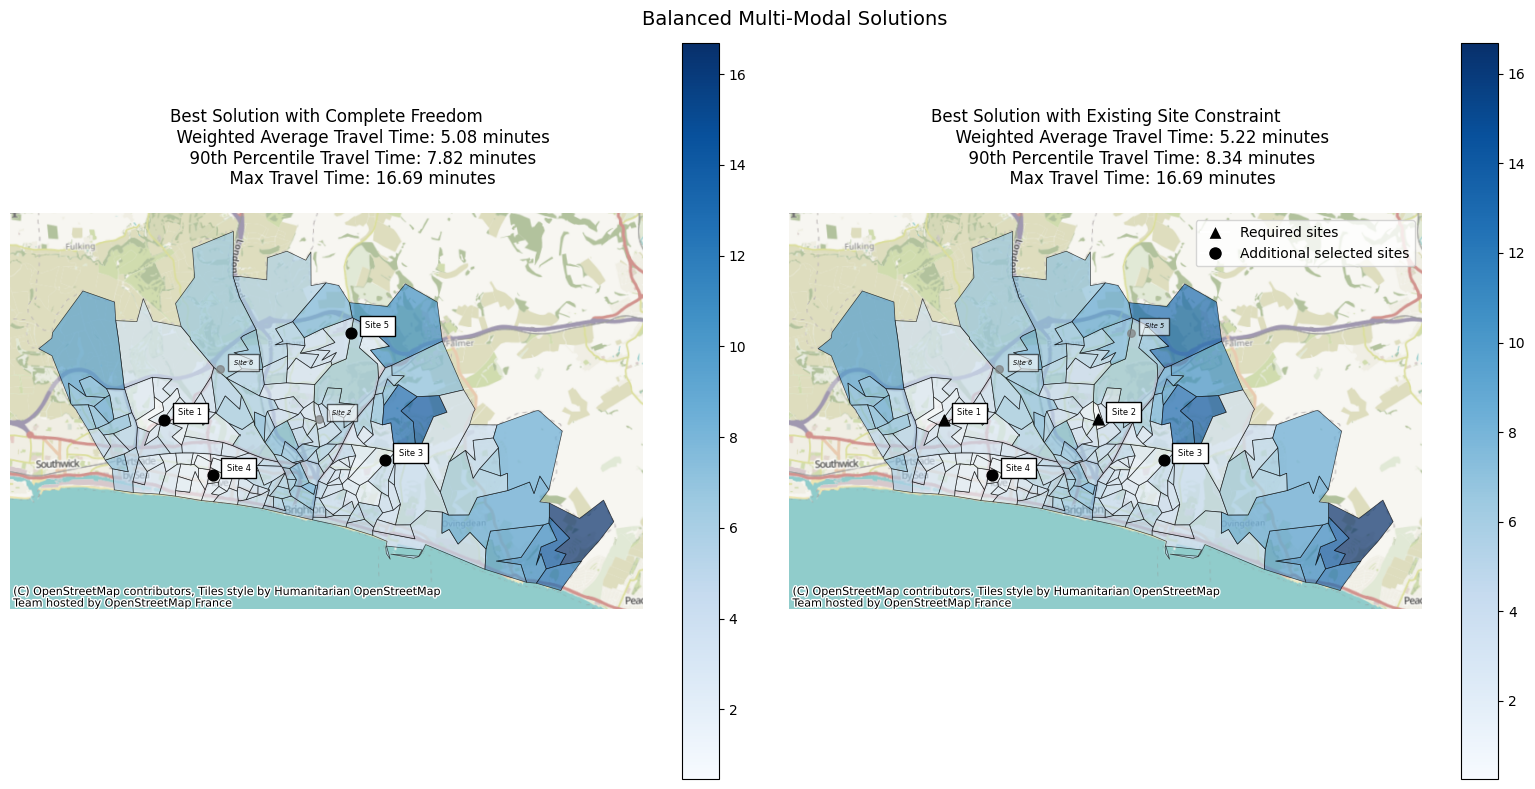

In [29]:
from lokigi.site_solutions import SolutionComparator

comparison = SolutionComparator(
    solutions,
    solutions_existing_site_constraint,
    ("Free Reign", "Existing Sites Must be Included")
    )

comparison.plot_comparison(
    config_1={'site_indices': solutions.return_best_combination_site_indices(),
              'title': f'''Best Solution with Complete Freedom
              Weighted Average Travel Time: {solutions.return_best_combination_details()["weighted_average"].iloc[0]:.2f} minutes
              90th Percentile Travel Time: {solutions.return_best_combination_details()["90th_percentile"].iloc[0]:.2f} minutes
              Max Travel Time: {solutions.return_best_combination_details()["max"].iloc[0]:.2f} minutes
              ''',
              'label_all_locations': True,
              },
    config_2={'site_indices': solutions_existing_site_constraint.return_best_combination_site_indices(),
              'title': f'''Best Solution with Existing Site Constraint
              Weighted Average Travel Time: {solutions_existing_site_constraint.return_best_combination_details()["weighted_average"].iloc[0]:.2f} minutes
              90th Percentile Travel Time: {solutions_existing_site_constraint.return_best_combination_details()["90th_percentile"].iloc[0]:.2f} minutes
              Max Travel Time: {solutions_existing_site_constraint.return_best_combination_details()["max"].iloc[0]:.2f} minutes
              ''',
              'label_all_locations': True,
              },
    title='Balanced Multi-Modal Solutions'
);

This plot helps to highlight that in this instance, there is only a very small benefit to closing an existing site in favour of being able to use any combination of candidate sites. 